In [1]:
import numpy as np
import netket as nk
import jax
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

In [2]:
N = 8
data_file = f"../data/N{N}/results_N{N}_vs_T.txt"

with open(data_file, "r") as f:
    data = json.load(f)

T_array = np.array(data["T"])
energy_results = data["energy"]
entropy_results = data["entropy"]
free_energy_results = data["free_energy"]

In [3]:
from netket.operator.spin import sigmax, sigmaz

def hamltonian_system_anda_extended(Gamma, V, N, hi_system, hi_extended):
    H_system = 0
    H_extended = 0
    for i in range(N):
        H_system += Gamma * sigmax(hi_system, i)
        H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)
        H_extended += Gamma * sigmax(hi_extended, i)
        H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
    return H_system, H_extended

Gamma = -1.5  
V = -1
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
H_system, H_extended = hamltonian_system_anda_extended(Gamma, V, N, hi_system, hi_extended)

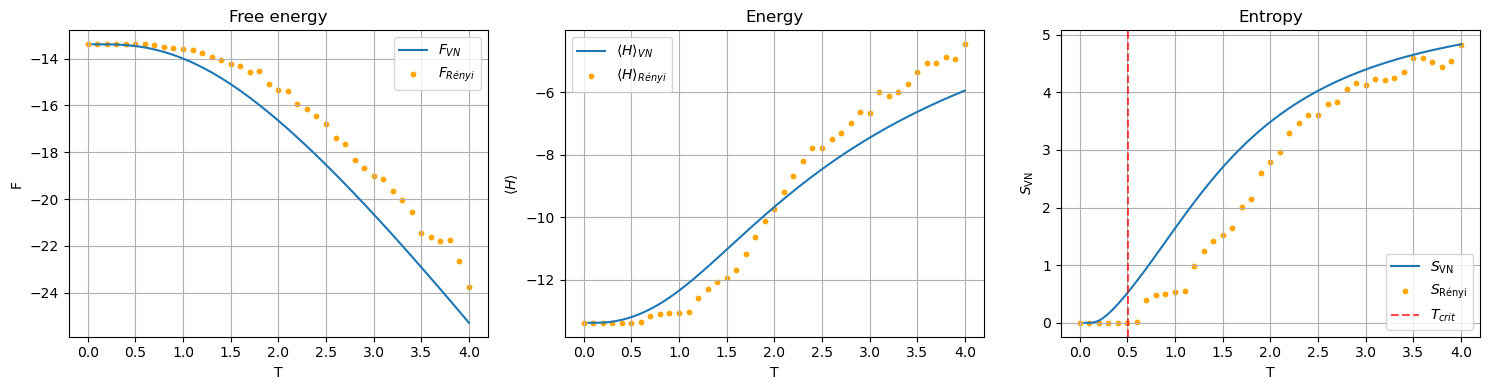

In [4]:
# --- Convertir H a matriz densa  ---
H_matrix = H_system.to_dense()

# --- Diagonalización (solo una vez) ---
eigvals, eigvecs = np.linalg.eigh(H_matrix)
t_c =(eigvals[1]-eigvals[0])/2

def canonical_ensemble(eigvals, eigvecs, T):
    """Calcula F, <H>, S_VN exactos para temperatura T."""
    # Poblaciones de Boltzmann
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)  
    pops = np.exp(log_pops)
    Z = pops.sum()
    pops /= Z
    
    # Energía
    energy = np.sum(pops * eigvals)
    
    # Entropía de Von Neumann (en base diagonal de H, ρ ya es diagonal)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    
    # Energía libre
    F = energy - T * S_VN
    
    return F, energy, S_VN

# --- Barrido en temperatura ---
temperatures = np.linspace(0.05, 4, 200)  # evitar T=0

F_list, E_list, S_list = [], [], []
for T in temperatures:
    F, E, S = canonical_ensemble(eigvals, eigvecs, T)
    F_list.append(F)
    E_list.append(E)
    S_list.append(S)

F_arr = np.array(F_list)
E_arr = np.array(E_list)
S_arr = np.array(S_list)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(temperatures, F_arr, label=r'$F_{VN}$')
axes[0].scatter(T_array, free_energy_results, color="orange", label=r'$F_{Rényi}$', s=10)
axes[0].set_xlabel('T'); axes[0].set_ylabel('F')
axes[0].set_title('Free energy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(temperatures, E_arr, label=r'$\langle H \rangle_{VN}$')
axes[1].scatter(T_array, energy_results, color="orange", label=r'$\langle H \rangle_{Rényi}$', s=10)
axes[1].set_xlabel('T'); axes[1].set_ylabel(r'$\langle H \rangle$')
axes[1].set_title('Energy')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(temperatures, S_arr, label=r'$S_\mathrm{VN}$')
axes[2].scatter(T_array, entropy_results, color="orange", label=r'$S_\mathrm{Rényi}$', s=10)
axes[2].set_xlabel('T'); axes[2].set_ylabel(r'$S_\mathrm{VN}$')
axes[2].axvline(x=t_c, color='red', linestyle='--', alpha=0.7, label=r"$T_{crit}$")
axes[2].set_title('Entropy')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

In [5]:
def load_params(N, T, vstate):
    filename = f"../data/N{N}/params/params_T_{T:.3f}.msgpack"
    with open(filename, "rb") as f:
        params = serialization.from_bytes(vstate.parameters, f.read())
    vstate.parameters = params

def canonical_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el ensemble canónico a temperatura T.

    Parámetros
    ----------
    O : NetKet operator
    T : float
    eigvals : ndarray
    eigvecs : ndarray

    Returns
    -------
    float
    """

    # convertir operador a matriz densa
    O_matrix = O.to_dense()

    # poblaciones de Boltzmann (estables numéricamente)
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)

    pops = np.exp(log_pops)
    pops /= pops.sum()

    # <n|O|n>
    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    )

    # promedio térmico
    return np.sum(pops * O_diag).real

def renyi_expectation(O, vstate):
    """Expectation value <O> en el ensemble de Rényi."""
    return float(vstate.expect(O).mean.real)

Procesando temperaturas: 100%|██████████| 40/40 [00:16<00:00,  2.41it/s]


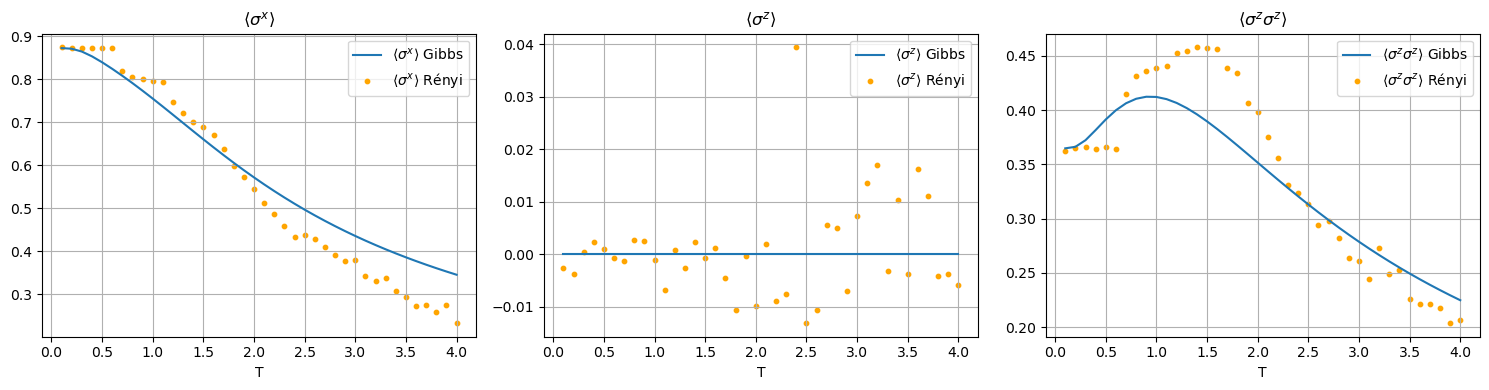

In [6]:
# Observables locales del sistema
O_x = sum(sigmax(hi_system, i) for i in range(N)) / N   # <σˣ> medio
O_z = sum(sigmaz(hi_system, i) for i in range(N)) / N   # <σᶻ> medio
O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i+1) % N) 
           for i in range(N)) / N                         # <σᶻσᶻ> medio

# Mismo operador pero en el hilbert extendido para el vstate
O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
O_z_ext = sum(sigmaz(hi_extended, i) for i in range(N)) / N
O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i+1) % N)
               for i in range(N)) / N

sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

T_array_compare = np.array(data["T"])

renyi_sx, renyi_sz, renyi_szz = [], [], []
gibbs_sx, gibbs_sz, gibbs_szz = [], [], []

T_filtradas = [T for T in T_array_compare if T >= 0.05]
for T in tqdm(T_filtradas, desc=f"Procesando temperaturas"):
    # Rényi: cargar parámetros y calcular
    load_params(N, T, vstate)
    renyi_sx.append(renyi_expectation(O_x_ext, vstate))
    renyi_sz.append(renyi_expectation(O_z_ext, vstate))
    renyi_szz.append(renyi_expectation(O_zz_ext, vstate))

    # Gibbs exacto
    gibbs_sx.append(canonical_expectation(O_x, T, eigvals, eigvecs))
    gibbs_sz.append(canonical_expectation(O_z, T, eigvals, eigvecs))
    gibbs_szz.append(canonical_expectation(O_zz, T, eigvals, eigvecs))

T_plot = T_array_compare[T_array_compare >= 0.05]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(T_plot, gibbs_sx, label=r'$\langle\sigma^x\rangle$ Gibbs')
axes[0].scatter(T_plot, renyi_sx, s=10, color='orange', label=r'$\langle\sigma^x\rangle$ Rényi')
axes[0].set_xlabel('T'); axes[0].set_title(r'$\langle\sigma^x\rangle$')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(T_plot, gibbs_sz, label=r'$\langle\sigma^z\rangle$ Gibbs')
axes[1].scatter(T_plot, renyi_sz, s=10, color='orange', label=r'$\langle\sigma^z\rangle$ Rényi')
axes[1].set_xlabel('T'); axes[1].set_title(r'$\langle\sigma^z\rangle$')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(T_plot, gibbs_szz, label=r'$\langle\sigma^z\sigma^z\rangle$ Gibbs')
axes[2].scatter(T_plot, renyi_szz, s=10, color='orange', label=r'$\langle\sigma^z\sigma^z\rangle$ Rényi')
axes[2].set_xlabel('T'); axes[2].set_title(r'$\langle\sigma^z\sigma^z\rangle$')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()


Procesando N = 2


N=2: 100%|██████████| 40/40 [00:00<00:00, 87.24it/s]



Procesando N = 4


N=4: 100%|██████████| 40/40 [00:00<00:00, 88.62it/s] 



Procesando N = 6


...

N=16: 100%|██████████| 40/40 [00:07<00:00,  5.01it/s]



Procesando N = 18


N=18: 100%|██████████| 40/40 [00:12<00:00,  3.08it/s]



Procesando N = 20


N=20: 100%|██████████| 40/40 [00:11<00:00,  3.37it/s]


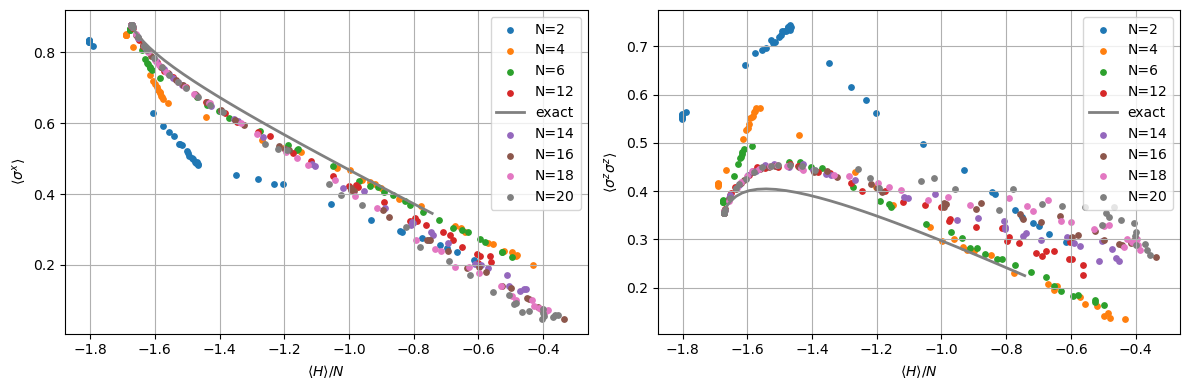

In [8]:
N_list = [2, 4, 6, 12, 14, 16, 18, 20]

T_array = np.array(data["T"])
T_array = T_array[T_array >= 0.05]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

exact_drawn = True

for N in N_list:
    if N==12:
        exact_drawn = False
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
    
    # Hamiltonianos
    H_system, H_extended = hamltonian_system_anda_extended(Gamma, V, N, hi_system, hi_extended)

    # diagonalización exacta
    if not exact_drawn:
        H_matrix = H_system.to_dense()
        eigvals, eigvecs = np.linalg.eigh(H_matrix)

    # Observables
    O_x = sum(sigmax(hi_system, i)  for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i)@sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i)@sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

    # Arrays resultados
    energies_renyi = []
    sx_renyi = []
    szz_renyi = []
    energies_exact = []
    sx_exact = []
    szz_exact = []

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        #Rényi
        load_params(N, T, vstate)
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr = vstate.expect(O_zz_ext).mean
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr)

        #Exacto
        if not exact_drawn:
            beta = 1.0 / T
            weights = np.exp(-beta * eigvals)
            Z = np.sum(weights)
            E_exact = np.sum(eigvals * weights) / Z
            e_density_exact = E_exact / N
            mx_exact = canonical_expectation(O_x, T, eigvals, eigvecs)
            corr_exact = canonical_expectation(O_zz, T, eigvals, eigvecs)
            energies_exact.append(e_density_exact)
            sx_exact.append(mx_exact)
            szz_exact.append(corr_exact)

    #Plot Rényi
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")

    # Plot exacto (una vez)
    if not exact_drawn:
        axes[0].plot(energies_exact, sx_exact, color="gray", linewidth=2, label="exact")
        axes[1].plot(energies_exact, szz_exact, color="gray", linewidth=2, label="exact")
        exact_drawn = True


# Formato final
axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")

axes[0].grid(True)
axes[1].grid(True)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
N_list = [2, 4, 6, 8, 10, 12]
T_array = np.linspace(0.1, 4.0, 40)

errors = []

def canonical_expectation_fast(O_diag, T, eigvals):

    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)

    pops = np.exp(log_pops)
    pops /= pops.sum()

    return np.sum(pops * O_diag)
    
for N in N_list:

    print(f"N = {N}")

    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)

    sampler = nk.sampler.ARDirectSampler(hi_extended)

    model = nk.models.ARNNDense(
        hilbert=hi_extended,
        layers=1,
        features=16,
        activation=jax.nn.gelu,
    )

    vstate = nk.vqs.MCState(
        sampler,
        model,
        n_samples=40960,
    )

    # --- Hamiltoniano sistema y extendido---
    H_system = 0
    H_extended = 0

    for i in range(N):
        H_system += Gamma * sigmax(hi_system, i)
        H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)
        
    for i in range(N):
        H_extended += Gamma * sigmax(hi_extended, i)
        H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

    # --- diagonalización ---
    H_matrix = H_system.to_dense()

    eigvals, eigvecs = np.linalg.eigh(H_matrix)

    # --- operadores en sistema y extendido ---
    O_sys = H_system
    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_sys.to_dense() @ eigvecs,
    ).real
    O_ext = H_extended

    error_sum = 0.0

    for T in T_array:

        # cargar parámetros entrenados a esa T
        load_params(N, T, vstate)

        # Rényi
        renyi_val = vstate.expect(O_ext).mean

        # canonical
        canonical_val = canonical_expectation_fast(
            O_diag,
            T,
            eigvals
        )

        error_sum += abs(renyi_val - canonical_val)

    # promedio sobre T
    error_mean = error_sum / len(T_array) /N

    print("error_mean =", error_mean)

    errors.append(error_mean)

N = 2
error_mean = 0.11565980703782079
N = 4
error_mean = 0.135445051615466
N = 6
error_mean = 0.10386972045078824
N = 8
error_mean = 0.08770489967854986
N = 10
error_mean = 0.08678312659818424
N = 12
error_mean = 0.09367957829234046


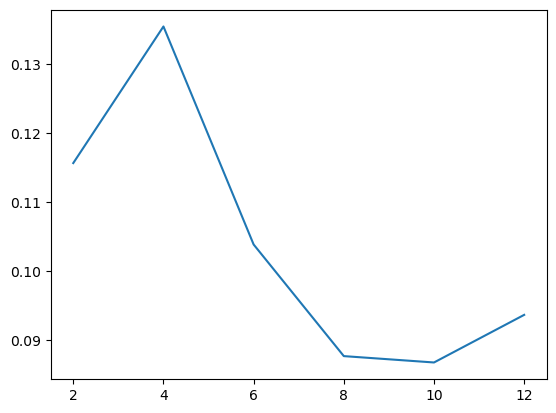

In [20]:
plt.plot(N_list, errors)